# Time dependent ITER simulation

In [1]:
ENV["JULIA_PKG_DEVDIR"] = joinpath(@__DIR__, "iter_test", "dev")
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0
import Pkg; Pkg.activate("iter_test")
Pkg.add("Plots")
Pkg.develop(["TurbulentTransport", "IMAS", "FUSE"])
Pkg.resolve()
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 1
using Plots;
using FUSE
FUSE.ProgressMeter.ijulia_behavior(:clear);

  Activating project at `~/.julia/dev/FuseExamples/iter_test`
   Resolving package versions...
  No Changes to `~/.julia/dev/FuseExamples/iter_test/Project.toml`
  No Changes to `~/.julia/dev/FuseExamples/iter_test/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/dev/FuseExamples/iter_test/Project.toml`
  No Changes to `~/.julia/dev/FuseExamples/iter_test/Manifest.toml`
  No Changes to `~/.julia/dev/FuseExamples/iter_test/Project.toml`
  No Changes to `~/.julia/dev/FuseExamples/iter_test/Manifest.toml`
[ Info: Precompiling FUSE [e64856f0-3bb8-4376-b4b7-c03396503992] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2), wrong source (6), incompatible header (4), mismatched flags (4))


In [6]:
reload = false
if reload
    dd, ini, act = FUSE.load("iter_stationary");
else
    ini, act = FUSE.case_parameters(:ITER; init_from=:ods);
    dd = IMAS.dd()
    FUSE.init(dd, ini, act)
    
    ini, _ = FUSE.case_parameters(:ITER; init_from=:scalars, time_dependent=true);

    ini.time.pulse_shedule_time_basis = range(0, 300; step=1.0)
    ini.time.simulation_start = 50.0;

    rampup_ends = 10.0

    ini.rampup.side = :lfs
    ini.rampup.ends_at = rampup_ends
    ini.rampup.diverted_at = rampup_ends * 0.8

    ini.equilibrium.pressure_core = t -> ramp(t / rampup_ends) .^ 2 * 0.643e6
    ini.equilibrium.ip = t -> ramp(t / rampup_ends) * 14E6 + ramp((t - 100) / 100) * 1E6

    ini.nb_unit[1].power_launched = t -> (1 .+ ramp((t - 100) / 100)) * 16.7e6
    ini.ec_launcher[1].power_launched = t -> (1 .+ ramp((t - 100) / 100)) * 10E6
    ini.ic_antenna[1].power_launched = t -> (1 .+ ramp((t - 100) / 100)) * 12E6
    ini.lh_antenna[1].power_launched = t -> (1 .+ ramp((t - 100) / 100)) * 5E6
    ini.pellet_launcher[1].frequency = t -> (1 .+ ramp((t - 100) / 100)) * 0.01 # Hz

    # the same ip(t) can be defined with unit pulse shaping functions...
    ini.equilibrium.ip = t -> ramp(t / 10.0) * 13E6 + ramp((t - 100) / 100) * 2E6;

    # ...or by a `sequence(t, t_y_tuple_sequence)`
    ini.equilibrium.ip = t -> sequence(t, [(0.0, 0.0), (10.0, 13.0E6), (100.0, 13.0E6), (200.0, 15.0E6)]);
    
    FUSE.init(dd, ini, act; initialize_hardware=false);

    act.ActorStationaryPlasma.convergence_error = 2E-2
    act.ActorStationaryPlasma.max_iterations = 5

    act.ActorSteadyStateCurrent.current_relaxation_radius = 0.2

    act.ActorFluxMatcher.verbose = true
    act.ActorFluxMatcher.relax = 0.5

    FUSE.ActorStationaryPlasma(dd, act; verbose=false)
    
    FUSE.save("iter_stationary", dd, ini, act);
    
end
@checkin :stationary dd ini act;

Calls: 62    Time: 0:00:00
            error: 0.01479412424003522
     Pfusion [MW]: 134.49020968614954
        Ti0 [keV]: 13.136827607369149
        Te0 [keV]: 14.891502788158231
   ne0 [10²⁰ m⁻³]: 0.9924743158833736
actors:  Current
actors:   QED
actors:  Equilibrium
actors:   FRESCO
actors:  --------------- 5/5 @ 55.12%


Progress:   4%|█                          |  ETA: 0:02:02 ( 0.23  s/it)
       start time: 50.0
         end time: 350.0
             time: 62.5
            stage: Equilibrium (1/2)
          Ip [MA]: -32.75962984912189
        Ti0 [keV]: 12.711058541975738
        Te0 [keV]: 14.20477415883756
   ne0 [10²⁰ m⁻³]: 0.9894964807140376
        max(zeff): 2.0026806275555944

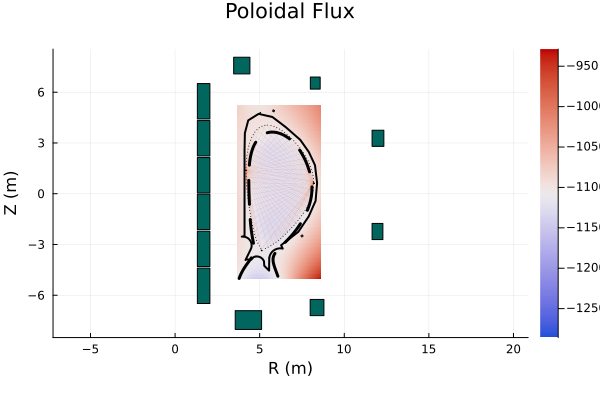

LoadError: "Found multiple minimum Ψ points: (54, 39) and (59, 90)"

In [7]:
@checkout :stationary dd ini act;

# For people interested in controls, the FuseExchangeProtocol can be used run a co-simulation with a controller external to FUSE
#IMAS.fxp_connect(dd)

act.ActorDynamicPlasma.Nt = 60
act.ActorDynamicPlasma.Δt = 300.0

act.ActorDynamicPlasma.evolve_current = true
act.ActorDynamicPlasma.evolve_equilibrium = true
act.ActorDynamicPlasma.evolve_transport = true
act.ActorDynamicPlasma.evolve_hcd = true
act.ActorDynamicPlasma.evolve_pf_active = false
act.ActorDynamicPlasma.evolve_pedestal = true

act.ActorDynamicPlasma.ip_controller = true
act.ActorDynamicPlasma.time_derivatives_sources = true

actor = FUSE.ActorDynamicPlasma(dd, act; verbose=true);

@checkin :time_dep_dt dd ini act actor;

In [4]:
act.ActorEquilibrium.model

:FRESCO

In [8]:
act.ActorFluxMatcher

ActorFluxMatcher
├─ rho_transport{AbstractVector{Float64}} ➡ 0.25:0.1:0.85 ρ transport grid
├─ evolve_Ti{Symbol} ➡ :flux_match Ion temperature `:flux_match` or keep `:fixed` [:flux_match, :fixed]
├─ evolve_Te{Symbol} ➡ :flux_match Electron temperature `:flux_match` or keep `:fixed` [:flux_match, :fixed]
├─ evolve_densities{Union{Symbol, AbstractDict}} ➡ :flux_match * `:fixed`: no density evolution * `:flux_match:` electron
│  flux-match and ions match ne scale while keeping quasi-neutrality, giving a flat zeff * `:zeff:` electron flux-match and
│  ions scaled to keep zeff constant while keeping quasi-neutrality * Dict to specify which species are `:flux_match`, kept
│  `:fixed`, used to enforce `:quasi_neutrality`, or scaled to `:match_ne_scale`
├─ evolve_rotation{Symbol} ➡ :fixed Rotation `:flux_match` or keep `:fixed` [:flux_match, :fixed]
├─ evolve_pedestal{Bool} ➡ true Evolve the pedestal at each iteration
├─ evolve_plasma_sources{Bool} ➡ true Update the plasma sources at each iter